In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('/content/loan_prediction.csv')

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [8]:
# Fill categorical missing values
categorical_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed',
    'Loan_Amount_Term',
    'Credit_History'
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical missing values
df['LoanAmount'] = df['LoanAmount'].fillna(
    df['LoanAmount'].mean()
)

In [9]:
df['Dependents'] = df['Dependents'].replace('3+', 3)

df['Dependents'] = df['Dependents'].astype(int)

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

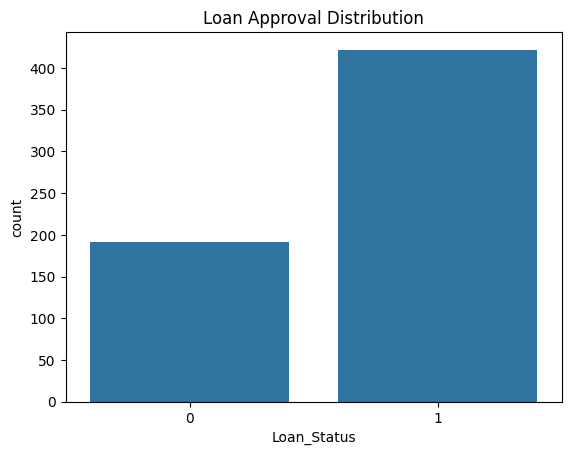

In [11]:
#exploratory data analysis
sns.countplot(x='Loan_Status', data=df)

plt.title("Loan Approval Distribution")

plt.show()

In [13]:
df.drop('Loan_ID', axis=1, inplace=True)

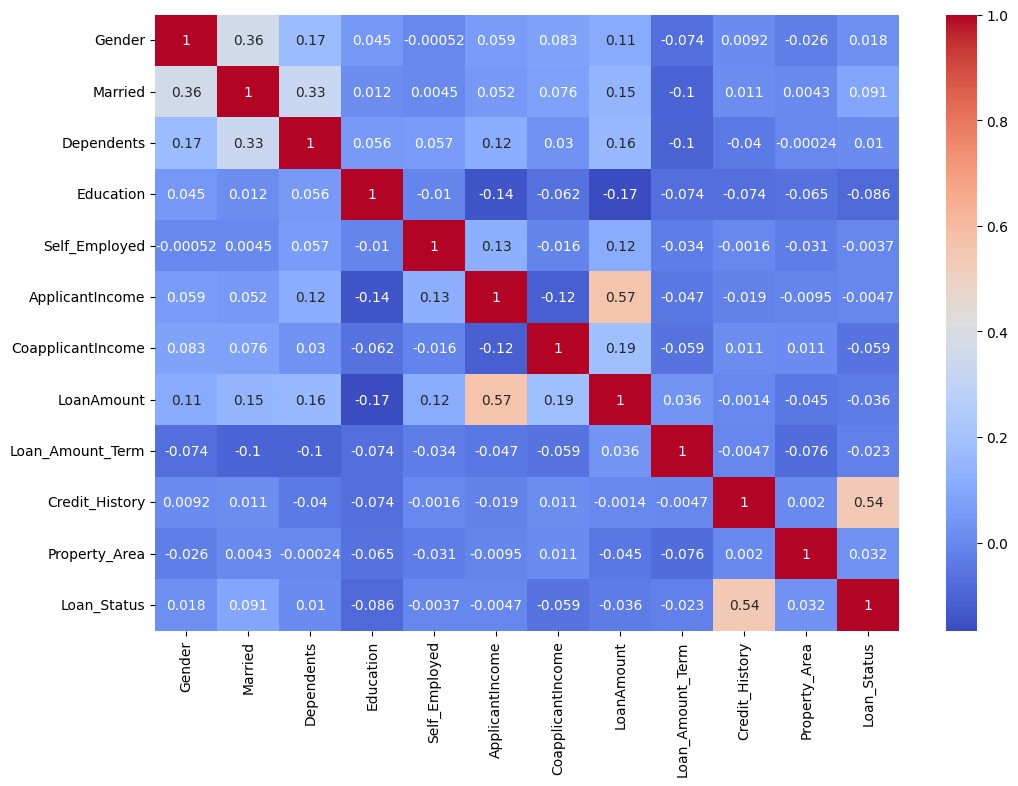

In [14]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [15]:
#defining features and target
X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
#train-logistic-regression-model
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=5000,
    solver='liblinear'
)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=5000, solver='liblinear')

In [20]:
#making predictions
y_pred = lr_model.predict(X_test)

In [21]:
#evaluating the model
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy: 0.7886178861788617

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



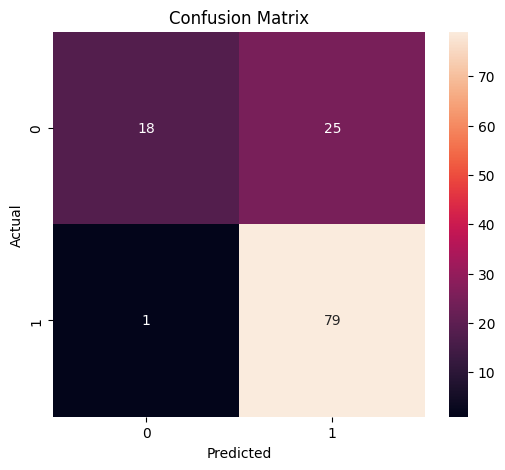

In [22]:
#confusion-matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [25]:
#random-forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7642276422764228


In [26]:
#feature-importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

              Feature  Importance
9      Credit_History    0.262729
5     ApplicantIncome    0.197369
7          LoanAmount    0.191891
6   CoapplicantIncome    0.113623
8    Loan_Amount_Term    0.050583
10      Property_Area    0.049363
2          Dependents    0.047505
1             Married    0.023255
3           Education    0.022147
0              Gender    0.021512
4       Self_Employed    0.020023


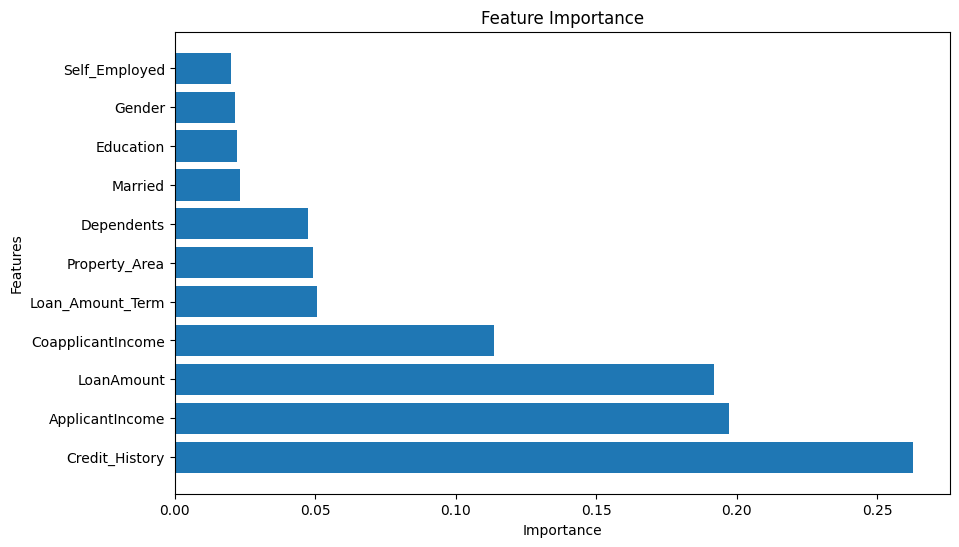

In [27]:
#visualization
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Importance")

plt.ylabel("Features")

plt.title("Feature Importance")

plt.show()

In [28]:
import pickle

pickle.dump(
    rf_model,
    open('loan_approval_model.pkl', 'wb')
)

In [29]:
print("""
Conclusion:

The project successfully predicted loan approval
status using Machine Learning classification models.

Logistic Regression provided baseline performance,
while Random Forest improved prediction accuracy.

The project involved:
- Data preprocessing
- Missing value handling
- Label encoding
- Model training
- Evaluation
- Feature importance analysis
""")


Conclusion:

The project successfully predicted loan approval
status using Machine Learning classification models.

Logistic Regression provided baseline performance,
while Random Forest improved prediction accuracy.

The project involved:
- Data preprocessing
- Missing value handling
- Label encoding
- Model training
- Evaluation
- Feature importance analysis

